# Capability Group Analysis

Analyzes the locked capability assignments (from `capability_defs.json`) for the
~852 callee functions reachable from command/spell/spec entry points.

**Focus:**
1. Load locked group assignments and resolve embeddings
2. **Intra-group cohesion** — how tightly clustered is each group?
3. **Inter-group similarity** — which groups overlap? Which functions fit better elsewhere?
4. **t-SNE visualisation** — per-group and global embedding landscape

Uses `EmbeddingRefiner` from the clustering pipeline for similarity matrices,
outlier detection, and regroup suggestions.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# ── Setup & imports ──────────────────────────────────────────────────
from __future__ import annotations

import json
import sys
import pickle
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

HERE = Path(".").resolve()
CLUSTERING_DIR = HERE / "clustering"
if str(CLUSTERING_DIR) not in sys.path:
    sys.path.insert(0, str(CLUSTERING_DIR))

import clustering.doc_db as ddb
import clustering.doxygen_graph as dg
import clustering.doxygen_parse as dp
import openai_embeddings as oai_emb
from embedding_refiner import EmbeddingRefiner
from subsystem_utils import Subsystem

# ── Load artifacts ───────────────────────────────────────────────────
graph = dg.load_graph(CLUSTERING_DIR / "code_graph.gml")
entity_db = dp.load_db(CLUSTERING_DIR / "code_graph.json")
doc_db = ddb.DocumentDB()
doc_db.load(ddb.DOC_DB_PATH)

with open(HERE / "capability_defs.json") as f:
    CAPABILITY_DEFS: dict[str, dict] = json.load(f)

# Build quick lookups
GROUP_TYPE = {name: d["type"] for name, d in CAPABILITY_DEFS.items()}
TYPE_ORDER = ["utility", "infrastructure", "policy", "projection", "domain"]
TYPE_COLORS = {
    "utility":        "#7f7f7f",
    "infrastructure": "#8c564b",
    "policy":         "#d62728",
    "projection":     "#ff7f0e",
    "domain":         "#1f77b4",
}

# ── Initialise EmbeddingRefiner (backed by Qwen3-Embedding-8B via LM Studio) ──
refiner = EmbeddingRefiner(entity_db, graph, doc_db)
refiner.load_sbert_model()

print(f"Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges")
print(f"Entity DB: {len(entity_db.entities)} entities")
print(f"Doc DB: {doc_db.count()} documents")
type_summary = ", ".join(
    f"{t}={sum(1 for v in CAPABILITY_DEFS.values() if v['type'] == t)}"
    for t in TYPE_ORDER
)
print(f"Capability groups: {len(CAPABILITY_DEFS)} ({type_summary})")
print(f"Embedding endpoint: {oai_emb.BASE_URL}  model: {oai_emb.MODEL}")

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 8)})

2026-03-13 15:15:05.559 | INFO     | clustering.doxygen_graph:load_graph:421 - Graph loaded from /Users/QTE2333/repos/legacy/.ai/gen_docs/clustering/code_graph.gml, nodes: 14507, edges: 44544


Graph: 14507 nodes, 44544 edges
Entity DB: 5305 entities
Doc DB: 5293 documents
Capability groups: 28 (utility=6, infrastructure=3, policy=4, projection=2, domain=13)
Embedding endpoint: http://localhost:4000/v1  model: text-embedding-qwen3-embedding-8b


## Step 1: Extract transitive call trees

Find all entry-point functions — `do_*` (command handlers), `spell_*` (spell
effect implementations), and `spec_*` (NPC special functions) — then BFS along
`calls` edges to collect every reachable function. This captures the true
dependency footprint, including cross-group dependencies at depth ≥2.

Entry points are excluded from each other's callee sets.
We track call depth per callee for later analysis.

In [3]:
# ── Helpers ──────────────────────────────────────────────────────────
ENTRY_PREFIXES = ("do_", "spell_", "spec_")

def entry_point_name(sig: str) -> str:
    """Extract the short name (do_kill, spell_fireball, spec_guard) from a signature."""
    for prefix in ENTRY_PREFIXES:
        idx = sig.find(prefix)
        if idx >= 0:
            end = sig.find("(", idx)
            return sig[idx:end] if end >= 0 else sig[idx:]
    return sig

def bare_name(sig: str) -> str:
    paren = sig.find("(")
    if paren > 0:
        sig = sig[:paren]
    space = sig.rfind(" ")
    if space > 0:
        sig = sig[space + 1:]
    return sig

def is_entry_point(name: str) -> bool:
    """Check if a function name contains an entry-point prefix."""
    return any(f" {p}" in name or name.startswith(p) for p in ENTRY_PREFIXES)

def get_calls_successors(g, node_id):
    """Return set of nodes reachable via a single 'calls' edge from node_id."""
    return {v for _, v, ed in g.edges(node_id, data=True)
            if ed.get("type") == "calls"}

def transitive_callees_bfs(g, start_node, exclude_nodes):
    """BFS along 'calls' edges. Returns dict {node_id: min_depth}."""
    visited = {}
    queue = []
    for callee in get_calls_successors(g, start_node):
        if callee not in exclude_nodes and callee != start_node:
            visited[callee] = 1
            queue.append((callee, 1))
    
    while queue:
        node, depth = queue.pop(0)
        for callee in get_calls_successors(g, node):
            if callee not in visited and callee not in exclude_nodes:
                visited[callee] = depth + 1
                queue.append((callee, depth + 1))
    return visited

# ── Find entry points ────────────────────────────────────────────────
entry_points = [
    (n, d) for n, d in graph.nodes(data=True)
    if d.get("kind") == "function" and is_entry_point(d.get("name", ""))
]
entry_point_nodes = {n for n, _ in entry_points}

# Categorize
do_funcs = [(n, d) for n, d in entry_points if " do_" in d.get("name", "")]
spell_funcs = [(n, d) for n, d in entry_points if " spell_" in d.get("name", "")]
spec_funcs = [(n, d) for n, d in entry_points if " spec_" in d.get("name", "")]
print(f"Entry points: {len(entry_points)} total")
print(f"  do_*:    {len(do_funcs)} command handlers")
print(f"  spell_*: {len(spell_funcs)} spell effects")
print(f"  spec_*:  {len(spec_funcs)} NPC special functions")

# ── Collect transitive callees via BFS ───────────────────────────────
cmd_callees: dict[str, dict[str, int]] = {}  # entry_name -> {node_id: min_depth}
all_callee_nodes: set[str] = set()
callee_min_depth: dict[str, int] = {}  # global min depth across all entry points

for node_id, node_data in entry_points:
    cmd = entry_point_name(node_data.get("name", "?"))
    callees = transitive_callees_bfs(graph, node_id, entry_point_nodes)
    cmd_callees[cmd] = callees
    for nid, depth in callees.items():
        all_callee_nodes.add(nid)
        callee_min_depth[nid] = min(callee_min_depth.get(nid, 999), depth)

# ── Depth distribution ───────────────────────────────────────────────
depth_dist = Counter(callee_min_depth.values())
direct_only = {nid for nid, d in callee_min_depth.items() if d == 1}
deeper = all_callee_nodes - direct_only

print(f"\nUnique callees (transitive): {len(all_callee_nodes)}")
print(f"  Direct (depth 1): {len(direct_only)}")
print(f"  Deeper (depth ≥2): {len(deeper)}")
print(f"\nDepth distribution (min depth across all entry points):")
for d in sorted(depth_dist.keys()):
    print(f"  depth {d}: {depth_dist[d]} callees")

# Per-entry-point expansion
direct_counts = [sum(1 for d in c.values() if d == 1) for c in cmd_callees.values()]
total_counts = [len(c) for c in cmd_callees.values()]
print(f"\nPer-entry-point callee counts:")
print(f"  Direct: mean={np.mean(direct_counts):.1f}, median={np.median(direct_counts):.0f}, max={max(direct_counts)}")
print(f"  Total:  mean={np.mean(total_counts):.1f}, median={np.median(total_counts):.0f}, max={max(total_counts)}")

Entry points: 633 total
  do_*:    442 command handlers
  spell_*: 160 spell effects
  spec_*:  31 NPC special functions

Unique callees (transitive): 853
  Direct (depth 1): 559
  Deeper (depth ≥2): 294

Depth distribution (min depth across all entry points):
  depth 1: 559 callees
  depth 2: 194 callees
  depth 3: 57 callees
  depth 4: 28 callees
  depth 5: 12 callees
  depth 6: 2 callees
  depth 7: 1 callees

Per-entry-point callee counts:
  Direct: mean=8.4, median=7, max=52
  Total:  mean=122.2, median=95, max=418


## Step 2: Resolve callee metadata and documentation

For each callee node, resolve:
- bare function name (from graph node attributes)
- minimum call depth (from transitive BFS)
- entity ID (via `get_body_eid`)
- doc_db document (brief, details, rationale)
- full documentation text for embedding

In [4]:
# ── Resolve callee info ──────────────────────────────────────────────
callee_info: dict[str, dict] = {}

for node_id in sorted(all_callee_nodes):
    vd = graph.nodes[node_id]
    full_sig = vd.get("name", node_id)
    name = bare_name(full_sig)

    # Resolve entity and doc
    eid = None
    doc = None
    doc_text = None
    try:
        eid = dg.get_body_eid(entity_db, node_id)
        entity = entity_db.get(eid)
        if entity:
            doc = doc_db.get_doc(eid.compound, entity.signature)
            if doc is None and eid.compound in doc_db:
                for _sig, d in doc_db[eid.compound].items():
                    if d.name == entity.name and d.brief:
                        doc = d
                        break
    except Exception:
        pass

    if doc:
        doc_text = doc.to_doxygen()

    callee_info[node_id] = {
        "name": name,
        "sig": full_sig,
        "min_depth": callee_min_depth.get(node_id, 999),
        "eid": str(eid) if eid else None,
        "brief": doc.brief if doc else None,
        "doc_text": doc_text,
        "doc_mid": doc.mid if doc else None,
    }

documented = sum(1 for v in callee_info.values() if v["brief"])
has_text = sum(1 for v in callee_info.values() if v["doc_text"])
depth1 = sum(1 for v in callee_info.values() if v["min_depth"] == 1)
print(f"Callees: {len(callee_info)}")
print(f"  At depth 1: {depth1}")
print(f"  At depth ≥2: {len(callee_info) - depth1}")
print(f"  With doc brief: {documented}")
print(f"  With full doc text: {has_text}")
print(f"  Undocumented: {len(callee_info) - documented}")

Callees: 853
  At depth 1: 559
  At depth ≥2: 294
  With doc brief: 772
  With full doc text: 839
  Undocumented: 81


## Step 3: Resolve embeddings via EmbeddingRefiner

Reuse the `embeddings_cache.pkl` from the classify pipeline as a fast-path
(keyed by `doc.mid`).  For callees not in cache, delegate to
`refiner.generate_node_embedding_sbert(node_id)` — this resolves the entity,
retrieves its doc text, and SBERT-encodes it in one call.

In [5]:
EMBEDDING_CACHE = CLUSTERING_DIR / "embeddings_cache.pkl"

# Load cached embeddings (keyed by doc.mid) — fast path
with open(EMBEDDING_CACHE, "rb") as f:
    all_embeddings: dict[str, np.ndarray] = pickle.load(f)

sample_dim = next(iter(all_embeddings.values())).shape[0]
print(f"Cached embeddings: {len(all_embeddings)} ({sample_dim}d)")

# ── Resolve callee embeddings ────────────────────────────────────────
callee_embeddings: dict[str, np.ndarray] = {}
missing_embedding: list[str] = []

# 1. Try cache first (keyed by doc.mid)
for node_id, info in callee_info.items():
    mid = info["doc_mid"]
    if mid and mid in all_embeddings:
        callee_embeddings[node_id] = all_embeddings[mid]
    else:
        missing_embedding.append(node_id)

print(f"Callees with cached embedding: {len(callee_embeddings)}")
print(f"Callees missing from cache: {len(missing_embedding)}")

# 2. For missing callees, use refiner (now backed by OpenAI)
encoded_via_refiner = 0
still_missing = []
for nid in missing_embedding:
    emb = refiner.generate_node_embedding_sbert(nid)
    if emb is not None:
        callee_embeddings[nid] = emb
        encoded_via_refiner += 1
    else:
        still_missing.append(nid)

no_embedding = still_missing
print(f"Encoded via OpenAI fallback: {encoded_via_refiner}")
print(f"Total with embedding: {len(callee_embeddings)}/{len(all_callee_nodes)}")
print(f"No embedding (undocumented): {len(no_embedding)}")

# ── Build name→node_id lookup (bare name → node_id) ─────────────────
name_to_nid: dict[str, str] = {}
for nid, info in callee_info.items():
    name_to_nid[info["name"]] = nid  # last-wins for the 1 duplicate

print(f"Bare name → node_id mappings: {len(name_to_nid)}")

Cached embeddings: 5293 (4096d)
Callees with cached embedding: 839
Callees missing from cache: 14
Encoded via OpenAI fallback: 0
Total with embedding: 839/853
No embedding (undocumented): 14
Bare name → node_id mappings: 852


## Step 4: Load locked group assignments

Read the `locked` lists from `capability_defs.json` to build definitive group
memberships.  Functions are matched by bare name to the callee node IDs discovered
in step 1.  Any locked names missing from the callee pool (or without embeddings)
are reported.

In [6]:
# ── Build group assignments from locked lists ────────────────────────
group_members: dict[str, list[str]] = {}   # group → [node_id, ...]
group_embeddings: dict[str, dict[str, np.ndarray]] = {}  # for refiner
name_to_group: dict[str, str] = {}         # bare_name → group
unmatched_locked: list[tuple[str, str]] = []
no_emb_locked: list[tuple[str, str]] = []

for group_name, gdef in CAPABILITY_DEFS.items():
    locked_names = gdef.get("locked", [])
    nids = []
    embs = {}
    for fn_name in locked_names:
        name_to_group[fn_name] = group_name
        nid = name_to_nid.get(fn_name)
        if nid is None:
            unmatched_locked.append((fn_name, group_name))
            continue
        nids.append(nid)
        if nid in callee_embeddings:
            embs[nid] = callee_embeddings[nid]
        else:
            no_emb_locked.append((fn_name, group_name))
    group_members[group_name] = nids
    group_embeddings[group_name] = embs

total_locked = sum(len(gdef.get("locked", [])) for gdef in CAPABILITY_DEFS.values())
total_matched = sum(len(nids) for nids in group_members.values())
total_with_emb = sum(len(e) for e in group_embeddings.values())

print(f"Locked function names: {total_locked}")
print(f"Matched to callee pool: {total_matched}")
print(f"With embedding: {total_with_emb}")
print(f"Unmatched (not in callee pool): {len(unmatched_locked)}")
print(f"No embedding (undocumented): {len(no_emb_locked)}")

if unmatched_locked:
    print(f"\nUnmatched locked names:")
    for fn, g in unmatched_locked:
        print(f"  {g:25s}  {fn}")

# ── Build Subsystem objects for refiner ──────────────────────────────
subsystems: dict[str, Subsystem] = {}
for group_name in CAPABILITY_DEFS:
    nids = set(group_members.get(group_name, []))
    subsystems[group_name] = Subsystem(
        subsystem_id=group_name,
        name=group_name,
        nodes=nids,
        classification=GROUP_TYPE[group_name],
        description=CAPABILITY_DEFS[group_name]["desc"],
    )

print(f"\nGroup sizes (with embeddings):")
for t in TYPE_ORDER:
    groups = [(g, len(group_embeddings.get(g, {})))
              for g in CAPABILITY_DEFS if GROUP_TYPE[g] == t]
    for g, n in sorted(groups, key=lambda x: -x[1]):
        print(f"  [{t:14s}] {g:25s} {n:4d}")

Locked function names: 852
Matched to callee pool: 852
With embedding: 838
Unmatched (not in callee pool): 0
No embedding (undocumented): 14

Group sizes (with embeddings):
  [utility       ] string_ops                  42
  [utility       ] flags                       38
  [utility       ] parsing                     35
  [utility       ] memory                      20
  [utility       ] numerics                    12
  [utility       ] imaging                      4
  [infrastructure] persistence                 70
  [infrastructure] infrastructure              11
  [infrastructure] admin                        4
  [policy        ] state_rules                 57
  [policy        ] target_resolution           55
  [policy        ] attributes                  45
  [policy        ] visibility_rules            17
  [projection    ] output                      88
  [projection    ] display                     23
  [domain        ] affects                     89
  [domain        ] movement

## Step 5: Intra-group cohesion

Compute the pairwise cosine similarity matrix within each group.
Report average, min, and max off-diagonal similarity as cohesion metrics.

The range plot below shows the full **min → max** spread of pairwise similarities
within each group, with the mean marked.  Wide ranges indicate heterogeneous groups;
tight ranges indicate consistent internal similarity.

Group                          Type              N    Avg    Min    Max  Stability
---------------------------------------------------------------------------------------------------------
  string_ops                   utility          42  0.436  0.187  0.989  stable
  flags                        utility          38  0.529  0.167  0.952  stable
  parsing                      utility          35  0.354  0.111  0.935  stable
  memory                       utility          20  0.349  0.128  0.892  stable
  numerics                     utility          12  0.450  0.250  0.758  stable
  imaging                      utility           4  0.527  0.399  0.836  stable
  persistence                  infrastructure   70  0.341  0.084  0.924  stable
  infrastructure               infrastructure   11  0.377  0.161  0.729  stable
  admin                        infrastructure    4  0.483  0.381  0.652  stable
  state_rules                  policy           57  0.425  0.149  0.943  stable
  target_re

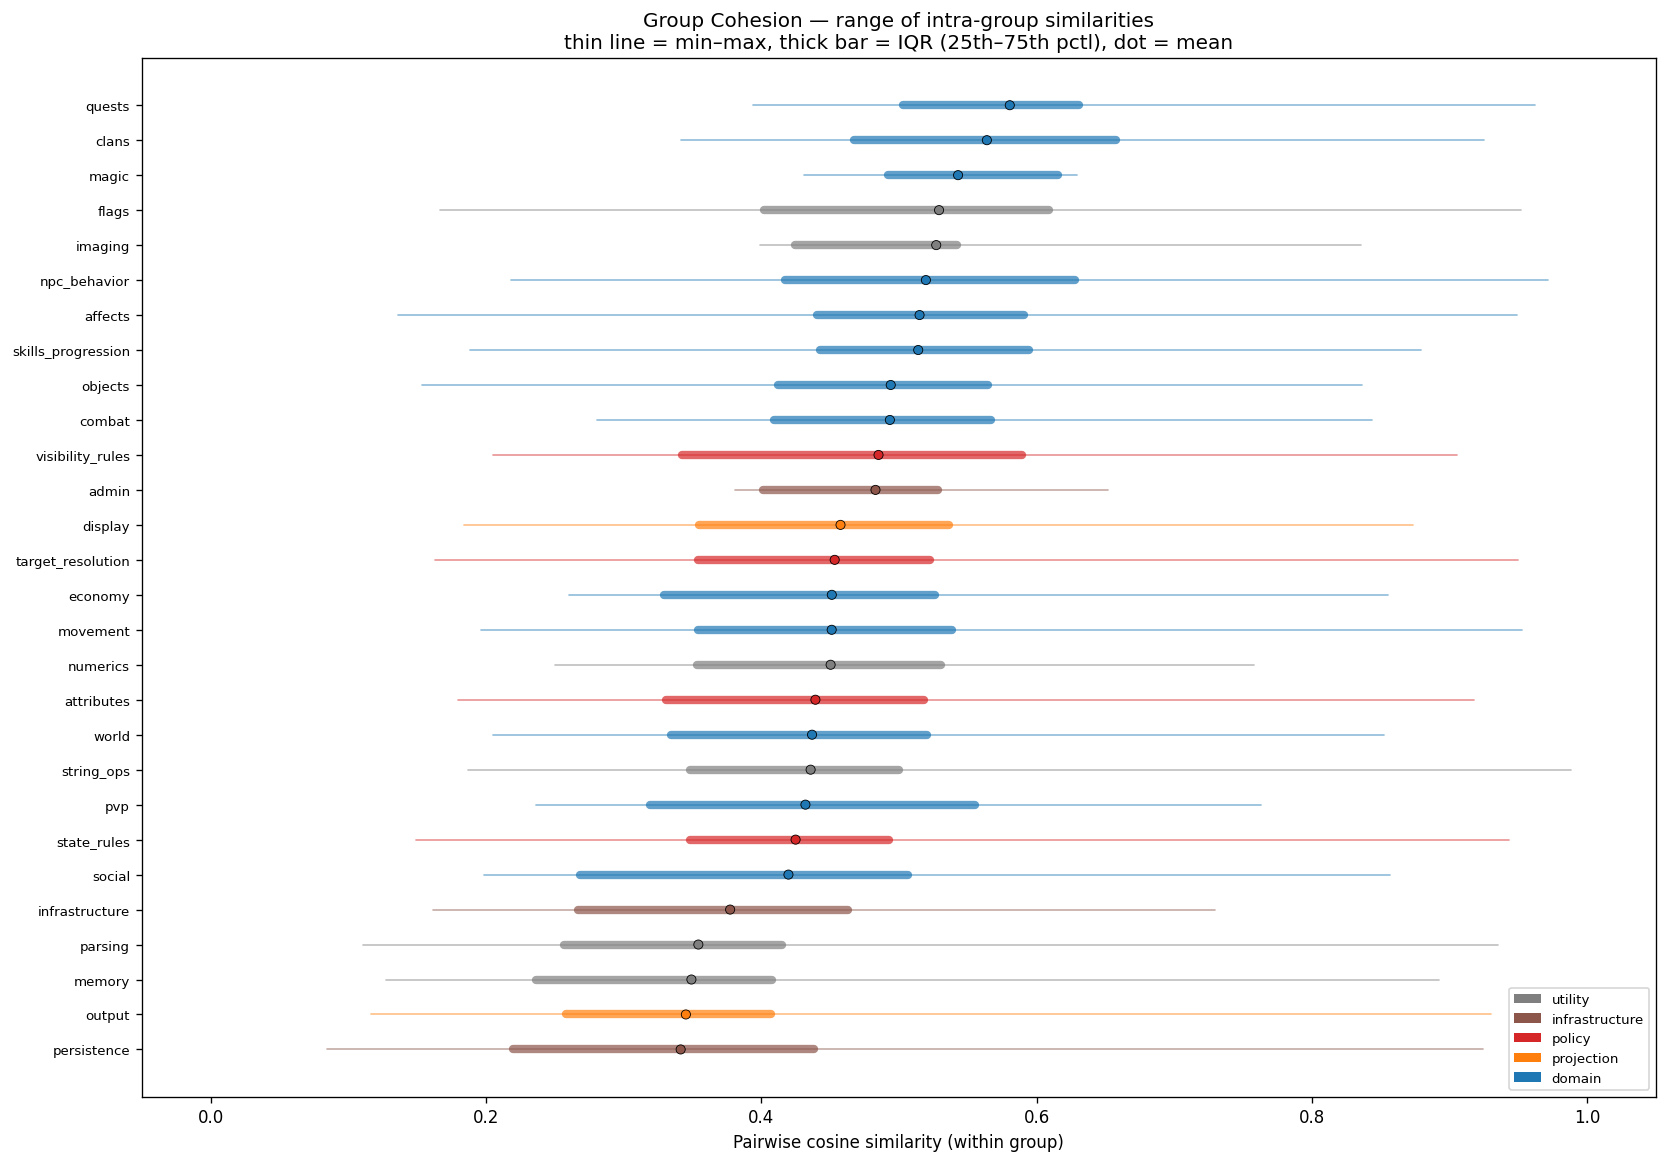

In [15]:
# ── Intra-group similarity via refiner ────────────────────────────────
sim_matrices = refiner.calculate_similarity_matrices(group_embeddings)

cohesion_rows = []
print(f"{'Group':30s} {'Type':14s} {'N':>4s}  {'Avg':>5s}  {'Min':>5s}  {'Max':>5s}  {'Stability'}")
print("-" * 105)

for t in TYPE_ORDER:
    groups = [g for g in CAPABILITY_DEFS if GROUP_TYPE[g] == t and g in sim_matrices]
    for g in sorted(groups, key=lambda g: -len(group_embeddings.get(g, {}))):
        sm = sim_matrices[g]
        mat = sm["matrix"]
        n = mat.shape[0]
        if n < 2:
            continue
        mask = ~np.eye(n, dtype=bool)
        off_diag = mat[mask]
        avg, mn, mx = np.mean(off_diag), np.min(off_diag), np.max(off_diag)
        q25, q75 = np.percentile(off_diag, [25, 75])
        stab = CAPABILITY_DEFS[g].get("stability", "")
        cohesion_rows.append((g, t, n, avg, mn, mx, q25, q75, stab))
        print(f"  {g:28s} {t:14s} {n:4d}  {avg:.3f}  {mn:.3f}  {mx:.3f}  {stab}")

# ── Cohesion range plot ──────────────────────────────────────────────
# Sort by mean cohesion (ascending → weakest at top)
rows_sorted = sorted(cohesion_rows, key=lambda r: r[3])
names  = [r[0] for r in rows_sorted]
avgs   = [r[3] for r in rows_sorted]
mins   = [r[4] for r in rows_sorted]
maxs   = [r[5] for r in rows_sorted]
q25s   = [r[6] for r in rows_sorted]
q75s   = [r[7] for r in rows_sorted]
colors = [TYPE_COLORS[r[1]] for r in rows_sorted]

fig, ax = plt.subplots(figsize=(14, max(6, len(names) * 0.35)))
y_pos = np.arange(len(names))

# Thin line: full min→max range
for i in range(len(names)):
    ax.plot([mins[i], maxs[i]], [y_pos[i], y_pos[i]],
            color=colors[i], linewidth=1, alpha=0.5, solid_capstyle="round")

# Thick bar: IQR (25th–75th percentile)
for i in range(len(names)):
    ax.plot([q25s[i], q75s[i]], [y_pos[i], y_pos[i]],
            color=colors[i], linewidth=5, alpha=0.7, solid_capstyle="round")

# Dot: mean
ax.scatter(avgs, y_pos, color=colors, s=30, zorder=5, edgecolors="black", linewidths=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel("Pairwise cosine similarity (within group)")
ax.set_title("Group Cohesion — range of intra-group similarities\n"
             "thin line = min–max, thick bar = IQR (25th–75th pctl), dot = mean")
ax.set_xlim(-0.05, 1.05)

# Legend for type colours
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=TYPE_COLORS[t], label=t) for t in TYPE_ORDER]
ax.legend(handles=legend_handles, loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## Step 6: Inter-group similarity matrix

Compute the mean centroid-to-centroid similarity between all group pairs.
High inter-group similarity suggests overlapping definitions or candidates for merging.

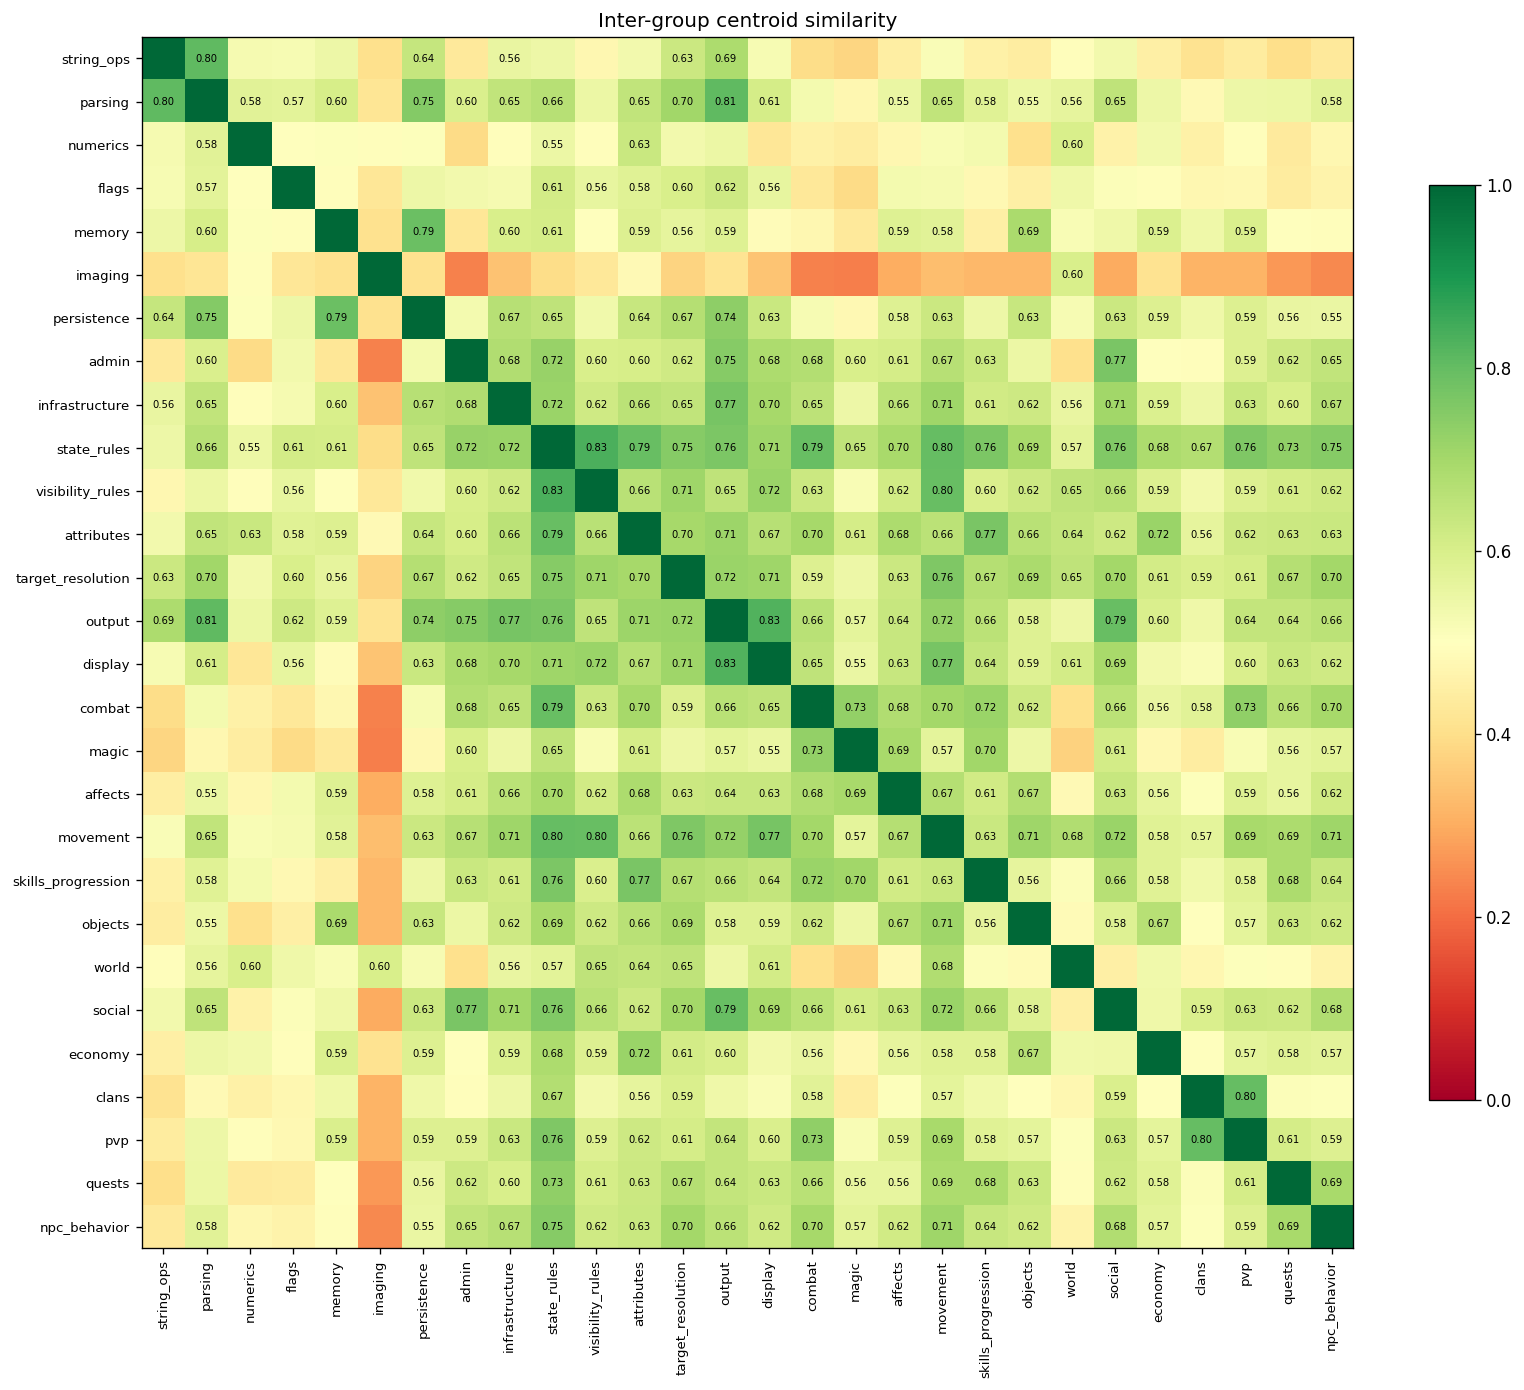


Top inter-group similarities (>0.55):
  0.833  state_rules               ↔ visibility_rules
  0.826  output                    ↔ display
  0.806  parsing                   ↔ output
  0.805  string_ops                ↔ parsing
  0.798  state_rules               ↔ movement
  0.798  clans                     ↔ pvp
  0.796  visibility_rules          ↔ movement
  0.795  output                    ↔ social
  0.794  state_rules               ↔ combat
  0.793  state_rules               ↔ attributes
  0.790  memory                    ↔ persistence
  0.772  infrastructure            ↔ output
  0.771  display                   ↔ movement
  0.768  admin                     ↔ social
  0.766  attributes                ↔ skills_progression
  0.765  state_rules               ↔ skills_progression
  0.763  state_rules               ↔ output
  0.760  state_rules               ↔ pvp
  0.759  target_resolution         ↔ movement
  0.755  state_rules               ↔ social
  0.752  parsing                  

In [8]:
# ── Compute group centroids ───────────────────────────────────────────
group_centroids: dict[str, np.ndarray] = {}
for g, embs in group_embeddings.items():
    if embs:
        group_centroids[g] = np.mean(np.stack(list(embs.values())), axis=0)

ordered_groups = [g for t in TYPE_ORDER for g in CAPABILITY_DEFS if GROUP_TYPE[g] == t and g in group_centroids]
centroid_matrix = np.stack([group_centroids[g] for g in ordered_groups])

# ── Inter-group cosine similarity ────────────────────────────────────
inter_sim = cosine_similarity(centroid_matrix, centroid_matrix)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(inter_sim, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(len(ordered_groups)))
ax.set_yticks(range(len(ordered_groups)))
ax.set_xticklabels(ordered_groups, rotation=90, fontsize=8)
ax.set_yticklabels(ordered_groups, fontsize=8)
ax.set_title("Inter-group centroid similarity")
fig.colorbar(im, ax=ax, shrink=0.7)

# Annotate cells with values
for i in range(len(ordered_groups)):
    for j in range(len(ordered_groups)):
        if i != j and inter_sim[i, j] > 0.55:
            ax.text(j, i, f"{inter_sim[i,j]:.2f}", ha="center", va="center", fontsize=6, color="black")

plt.tight_layout()
plt.show()

# ── Report high inter-group similarities ─────────────────────────────
print("\nTop inter-group similarities (>0.55):")
pairs = []
for i, g1 in enumerate(ordered_groups):
    for j, g2 in enumerate(ordered_groups):
        if i < j and inter_sim[i, j] > 0.55:
            pairs.append((g1, g2, inter_sim[i, j]))
pairs.sort(key=lambda x: -x[2])
for g1, g2, s in pairs:
    print(f"  {s:.3f}  {g1:25s} ↔ {g2}")

## Step 7: Outlier detection & regroup suggestions

Identify functions with low average similarity to their own group. Then check
whether any neighbouring group would be a better semantic fit.
Uses `EmbeddingRefiner.identify_outliers()` and `suggest_regroupings()`.

In [9]:
# ── Outlier detection ─────────────────────────────────────────────────
OUTLIER_THRESHOLD = 0.25  # fairly permissive — flags weakly-attached members
outliers = refiner.identify_outliers(subsystems, sim_matrices, threshold=OUTLIER_THRESHOLD)

print(f"Outliers (avg intra-group sim < {OUTLIER_THRESHOLD}): {len(outliers)}\n")

# Group outliers by their current group
outlier_by_group: dict[str, list] = defaultdict(list)
for o in outliers:
    outlier_by_group[o["current_subsystem"]].append(o)

for g in sorted(outlier_by_group, key=lambda g: -len(outlier_by_group[g])):
    members = outlier_by_group[g]
    print(f"[{g}] — {len(members)} outliers")
    for o in sorted(members, key=lambda x: x["average_similarity"]):
        info = callee_info.get(o["node_id"], {})
        brief = info.get("brief", "")
        b = f" — {brief[:55]}" if brief else ""
        print(f"  avg_sim={o['average_similarity']:.3f}  {o['name']:35s}{b}")

# ── Cross-group similarities & regroup suggestions ───────────────────
print(f"\n{'='*80}")
print("Computing cross-group similarities (this may take a moment)...")
cross_sims = refiner.calculate_cross_subsystem_similarities(group_embeddings)
suggestions = refiner.suggest_regroupings(outliers, cross_sims)

print(f"\nRegroup suggestions: {len(suggestions)}")
print(f"{'Name':35s} {'From':20s} {'To':20s} {'Δ sim':>7s}  {'Conf':>5s}")
print("-" * 95)
for s in suggestions[:40]:
    delta = s["suggested_similarity"] - s["current_similarity"]
    print(f"  {s['name']:33s} {s['current_subsystem']:20s} → {s['suggested_subsystem']:20s} "
          f"{delta:+.3f}  {s['confidence']:.2f}")

Outliers (avg intra-group sim < 0.25): 11

[persistence] — 7 outliers
  avg_sim=0.216  db_next_row                         — Advances to the next row in the SQLite query result.
  avg_sim=0.222  db_rows_affected                    — Retrieves the number of rows affected by the last execu
  avg_sim=0.231  db_close                            — Closes the database connection if it is open.
  avg_sim=0.232  db_open                             — Opens a connection to the database.
  avg_sim=0.234  load_war_events                     — Loads war events from files and populates the war event
  avg_sim=0.240  db_get_column_int                   — Retrieves an integer value from a specified column in t
  avg_sim=0.248  db_count                            — Executes a SQL COUNT query and returns the count of mat
[output] — 2 outliers
  avg_sim=0.240  db_error                            — Logs an error message related to a database operation a
  avg_sim=0.244  num_players                         

## Step 8: Per-group detail — members sorted by intra-group similarity

For manual review: list each group's members sorted by their average similarity
to fellow group members.  Functions near the bottom of each group are the most
"edge-case" members worth eyeballing.

In [10]:
# ── Per-group member detail ───────────────────────────────────────────
# Set SHOW_GROUP to a group name (or None for all, or a type name for a category)
SHOW_GROUP = None  # e.g. "affects", "combat", "domain", None for all

def member_similarities(sim_data):
    """Return list of (node_id, avg_sim_to_peers)."""
    nids = sim_data["node_ids"]
    mat = sim_data["matrix"]
    n = len(nids)
    result = []
    for i, nid in enumerate(nids):
        if n > 1:
            peer_sims = [mat[i, j] for j in range(n) if i != j]
            result.append((nid, np.mean(peer_sims)))
        else:
            result.append((nid, 1.0))
    return sorted(result, key=lambda x: -x[1])

groups_to_show = []
if SHOW_GROUP is None:
    groups_to_show = list(CAPABILITY_DEFS.keys())
elif SHOW_GROUP in TYPE_ORDER:
    groups_to_show = [g for g in CAPABILITY_DEFS if GROUP_TYPE[g] == SHOW_GROUP]
elif SHOW_GROUP in CAPABILITY_DEFS:
    groups_to_show = [SHOW_GROUP]
else:
    print(f"Unknown group or type: {SHOW_GROUP}")

for g in groups_to_show:
    if g not in sim_matrices:
        continue
    sm = sim_matrices[g]
    ranked = member_similarities(sm)
    n = len(ranked)
    if n == 0:
        continue
    avg_all = np.mean([s for _, s in ranked])
    print(f"\n{'='*80}")
    print(f"[{GROUP_TYPE[g]}/{g}] — {n} members, avg cohesion {avg_all:.3f}")
    print(f"  {'avg_sim':>7s}  {'name':40s}  brief")
    print(f"  {'-'*7}  {'-'*40}  {'-'*40}")
    for nid, avg_s in ranked:
        info = callee_info.get(nid, {})
        name = info.get("name", nid[:12])
        brief = info.get("brief", "")
        b = brief[:55] if brief else ""
        marker = " ◄" if avg_s < 0.15 else ""
        print(f"  {avg_s:7.3f}  {name:40s}  {b}{marker}")


[domain/combat] — 21 members, avg cohesion 0.493
  avg_sim  name                                      brief
  -------  ----------------------------------------  ----------------------------------------
    0.554  damage                                    Calculates and applies damage from an attack to a victi
    0.546  one_hit                                   Performs a single attack action from one character to a
    0.543  raw_kill                                  Handles the death of a character by stopping combat, tr
    0.533  multi_hit                                 Performs multiple attack actions for a character during
    0.514  check_dodge                               Checks whether a character successfully dodges an attac
    0.512  fireball_bash                             Calculates and applies a fireball bash effect that may 
    0.512  kill_off                                  Handles the death of a character, including logging, ex
    0.511  set_fighting           

## Step 9: t-SNE — global embedding landscape

Project all callee embeddings into 2D via t-SNE, coloured by locked group.
This gives a visual overview of cluster separation and overlap.

t-SNE input: 838 vectors, 4096d
t-SNE complete: (838, 2)


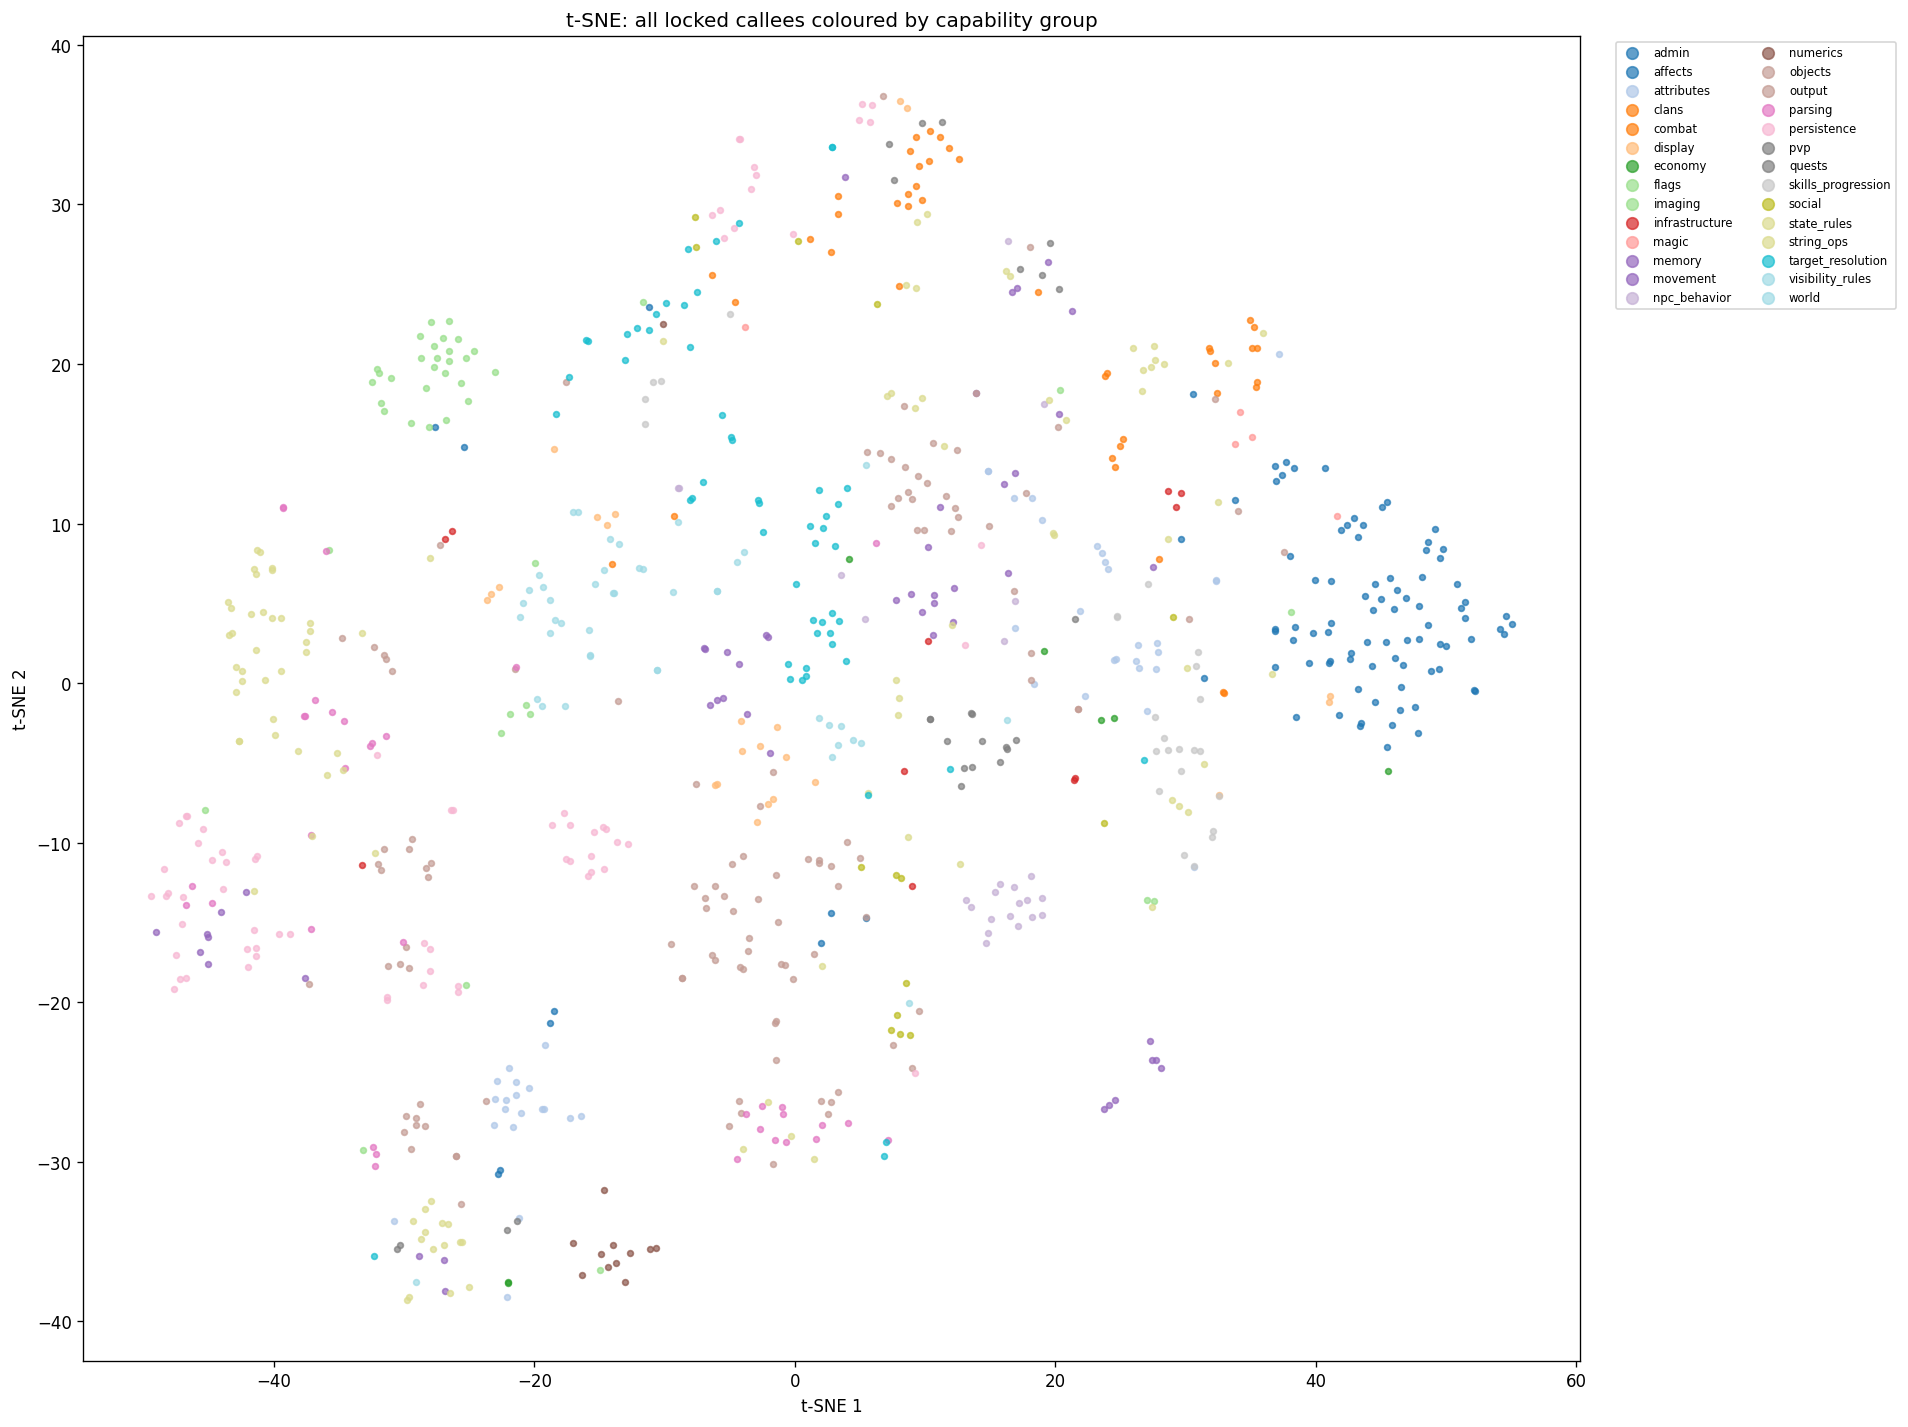

In [11]:
# ── Prepare data for t-SNE ────────────────────────────────────────────
# Collect all locked callees with embeddings
tsne_nids = []
tsne_groups = []
tsne_types = []
tsne_names = []

for g, embs in group_embeddings.items():
    for nid, vec in embs.items():
        tsne_nids.append(nid)
        tsne_groups.append(g)
        tsne_types.append(GROUP_TYPE[g])
        tsne_names.append(callee_info.get(nid, {}).get("name", "?"))

tsne_matrix = np.stack([callee_embeddings[nid] for nid in tsne_nids])
print(f"t-SNE input: {tsne_matrix.shape[0]} vectors, {tsne_matrix.shape[1]}d")

# ── Run t-SNE ────────────────────────────────────────────────────────
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto")
tsne_2d = tsne.fit_transform(tsne_matrix)
print(f"t-SNE complete: {tsne_2d.shape}")

# ── Assign colours per group ─────────────────────────────────────────
unique_groups = sorted(set(tsne_groups))
cmap = plt.colormaps.get_cmap("tab20").resampled(len(unique_groups))
group_color_map = {g: cmap(i) for i, g in enumerate(unique_groups)}

# ── Global scatter plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))
for g in unique_groups:
    idx = [i for i, gname in enumerate(tsne_groups) if gname == g]
    ax.scatter(tsne_2d[idx, 0], tsne_2d[idx, 1],
               c=[group_color_map[g]], label=g, s=12, alpha=0.7)

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7, ncol=2, markerscale=2)
ax.set_title("t-SNE: all locked callees coloured by capability group")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## Step 10: t-SNE — per-group detail plots

Highlight one group at a time against the greyed-out background of all other
functions.  Useful for spotting members that land far from the group cluster.

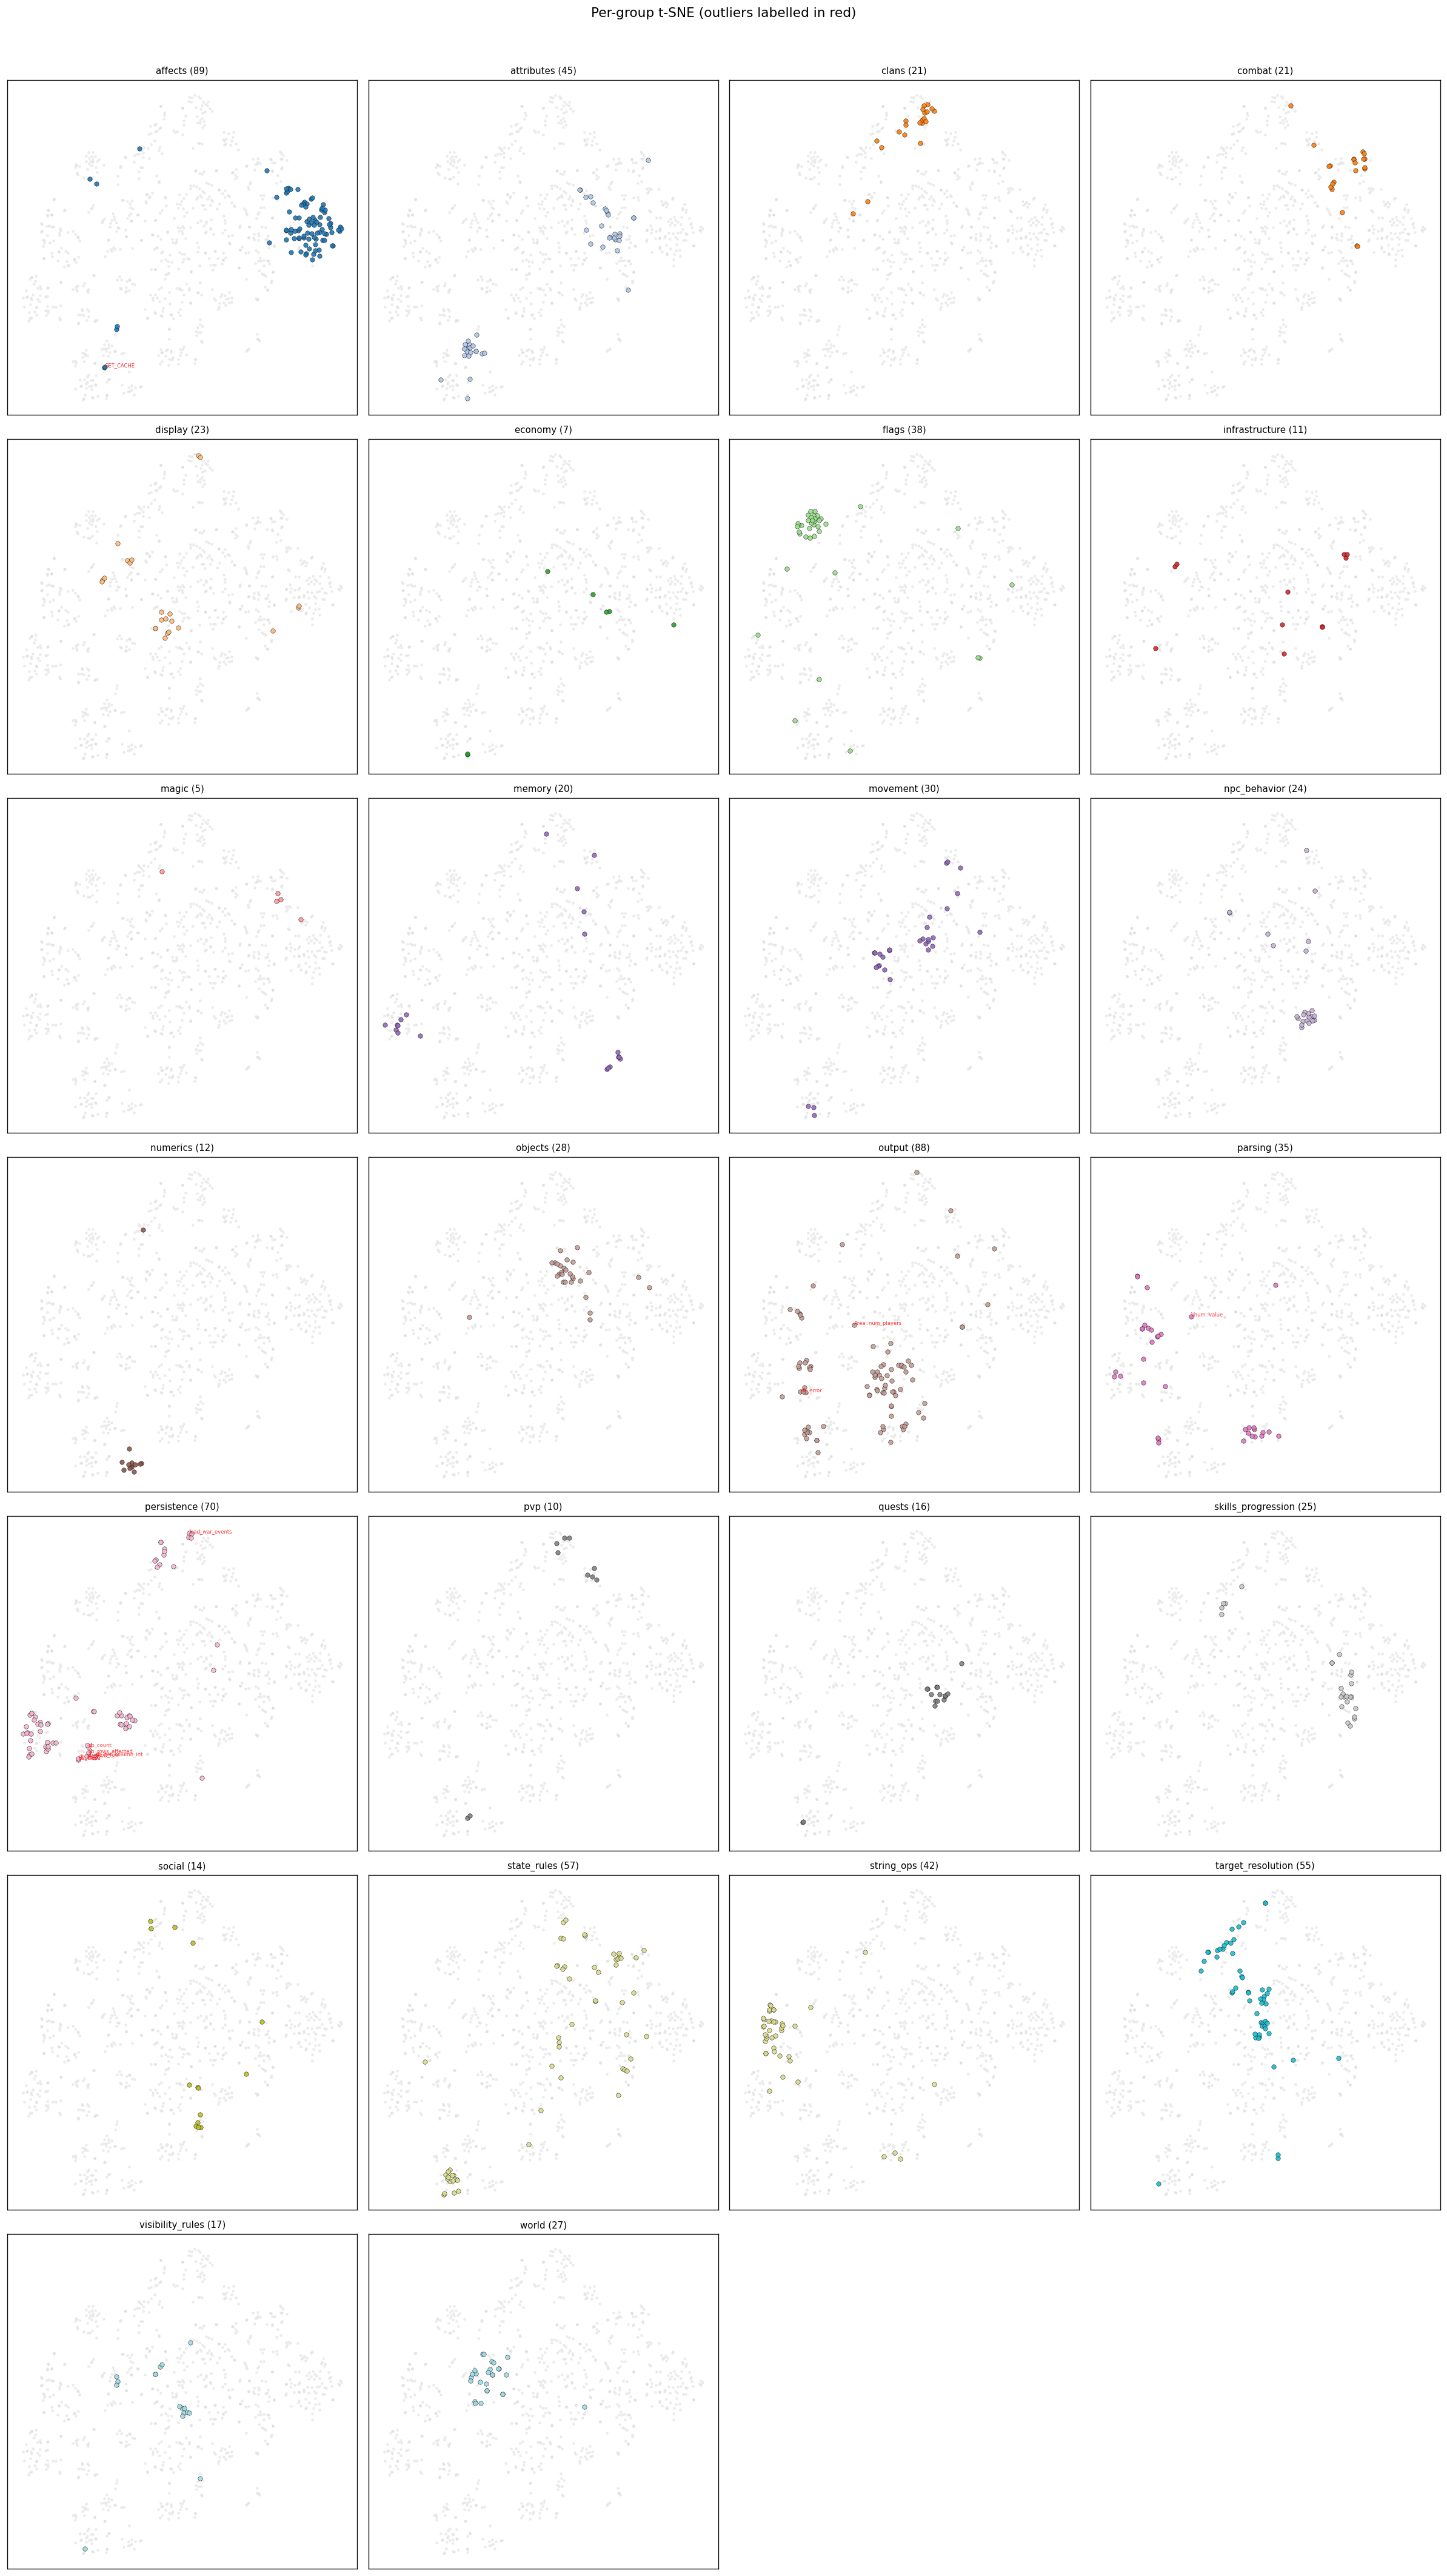

In [12]:
# ── Per-group t-SNE detail plots ──────────────────────────────────────
# Show groups with at least MIN_MEMBERS members
MIN_MEMBERS = 5
groups_to_plot = [g for g in unique_groups if sum(1 for gn in tsne_groups if gn == g) >= MIN_MEMBERS]

n_plots = len(groups_to_plot)
ncols = 4
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 5 * nrows))
axes = axes.flatten() if n_plots > 1 else [axes]

for idx, g in enumerate(groups_to_plot):
    ax = axes[idx]
    # Background: all other points in grey
    other_idx = [i for i, gn in enumerate(tsne_groups) if gn != g]
    ax.scatter(tsne_2d[other_idx, 0], tsne_2d[other_idx, 1],
               c="lightgrey", s=4, alpha=0.3)
    # Foreground: this group's points
    group_idx = [i for i, gn in enumerate(tsne_groups) if gn == g]
    ax.scatter(tsne_2d[group_idx, 0], tsne_2d[group_idx, 1],
               c=[group_color_map[g]], s=20, alpha=0.9, edgecolors="black", linewidths=0.3)

    # Label outlier members (those from step 7)
    outlier_nids_for_g = {o["node_id"] for o in outliers if o["current_subsystem"] == g}
    for i in group_idx:
        if tsne_nids[i] in outlier_nids_for_g:
            ax.annotate(tsne_names[i], (tsne_2d[i, 0], tsne_2d[i, 1]),
                       fontsize=5, alpha=0.8, color="red")

    ax.set_title(f"{g} ({len(group_idx)})", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

# Hide unused subplots
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Per-group t-SNE (outliers labelled in red)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ── Summary statistics ────────────────────────────────────────────────
total_locked_matched = sum(len(nids) for nids in group_members.values())
total_with_emb = sum(len(e) for e in group_embeddings.values())

# Per-group avg cohesion
cohesions = {}
for g in CAPABILITY_DEFS:
    if g in sim_matrices:
        mat = sim_matrices[g]["matrix"]
        n = mat.shape[0]
        if n >= 2:
            mask = ~np.eye(n, dtype=bool)
            cohesions[g] = np.mean(mat[mask])

overall_cohesion = np.mean(list(cohesions.values())) if cohesions else 0

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Groups: {len(CAPABILITY_DEFS)}")
print(f"Locked functions: {total_locked}")
print(f"Matched to callee pool: {total_locked_matched}")
print(f"With embeddings: {total_with_emb}")
print(f"Overall mean cohesion: {overall_cohesion:.3f}")
print(f"Outliers (< {OUTLIER_THRESHOLD}): {len(outliers)}")
print(f"Regroup suggestions: {len(suggestions)}")

print(f"\nGroups by cohesion:")
for g, c in sorted(cohesions.items(), key=lambda x: x[1]):
    n = len(group_embeddings.get(g, {}))
    print(f"  {c:.3f}  {g:25s} ({n:3d} members)  [{GROUP_TYPE[g]}]")

SUMMARY
Groups: 28
Locked functions: 852
Matched to callee pool: 852
With embeddings: 838
Overall mean cohesion: 0.460
Outliers (< 0.25): 11
Regroup suggestions: 10

Groups by cohesion:
  0.341  persistence               ( 70 members)  [infrastructure]
  0.345  output                    ( 88 members)  [projection]
  0.349  memory                    ( 20 members)  [utility]
  0.354  parsing                   ( 35 members)  [utility]
  0.377  infrastructure            ( 11 members)  [infrastructure]
  0.420  social                    ( 14 members)  [domain]
  0.425  state_rules               ( 57 members)  [policy]
  0.432  pvp                       ( 10 members)  [domain]
  0.436  string_ops                ( 42 members)  [utility]
  0.437  world                     ( 27 members)  [domain]
  0.439  attributes                ( 45 members)  [policy]
  0.450  numerics                  ( 12 members)  [utility]
  0.451  movement                  ( 30 members)  [domain]
  0.451  economy       

In [14]:
# ── Export locked classifications with cohesion metadata ──────────────
def _f(v):
    """Convert numpy scalars to Python float for JSON serialization."""
    return float(v) if hasattr(v, "item") else v

export = {
    "metadata": {
        "total_callees": len(all_callee_nodes),
        "locked": total_locked,
        "matched": total_locked_matched,
        "with_embedding": total_with_emb,
        "groups": len(CAPABILITY_DEFS),
        "overall_cohesion": round(float(overall_cohesion), 4),
        "outlier_threshold": OUTLIER_THRESHOLD,
        "n_outliers": len(outliers),
        "n_regroup_suggestions": len(suggestions),
    },
    "group_cohesion": {
        g: round(float(c), 4) for g, c in sorted(cohesions.items(), key=lambda x: x[1])
    },
    "outliers": [
        {
            "name": o["name"],
            "group": o["current_subsystem"],
            "avg_sim": round(float(o["average_similarity"]), 4),
        }
        for o in outliers
    ],
    "regroup_suggestions": [
        {
            "name": s["name"],
            "from": s["current_subsystem"],
            "to": s["suggested_subsystem"],
            "delta": round(float(s["suggested_similarity"] - s["current_similarity"]), 4),
            "confidence": round(float(s["confidence"]), 4),
        }
        for s in suggestions
    ],
}

out_path = HERE / "capability_classifications.json"
with open(out_path, "w") as f:
    json.dump(export, f, indent=2)
print(f"Exported to {out_path.name}")

Exported to capability_classifications.json
